In [ ]:
# ============================================================
# Демонстрация квартальных преобразований для раздела 3.3.1
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

try:
    from google.colab import drive
    drive.mount("/content/gdrive")
except Exception:
    pass

# ------------------------------------------------------------
# 1. Пути к данным
# ------------------------------------------------------------

BASE_DIR = Path("/content/gdrive/MyDrive/rostat")

# Файл может лежать либо в rostat/csv, либо прямо в rostat
possible_paths = [
    BASE_DIR / "csv" / "group_quarterly_dataset.csv",
]

DATA_PATH = None
for path in possible_paths:
    if path.exists():
        DATA_PATH = path
        break

if DATA_PATH is None:
    matches = list(BASE_DIR.rglob("group_quarterly_dataset.csv"))
    if len(matches) > 0:
        DATA_PATH = matches[0]

if DATA_PATH is None:
    raise FileNotFoundError(
        "Не найден файл group_quarterly_dataset.csv внутри /content/gdrive/MyDrive/rostat"
    )

OUT_DIR = BASE_DIR / "figures_for_diploma"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Используется файл:", DATA_PATH)
print("Папка для рисунков:", OUT_DIR)

# ------------------------------------------------------------
# 2. Загрузка квартального набора данных
# ------------------------------------------------------------

df = pd.read_csv(DATA_PATH, parse_dates=["period_end"])
df["period_end"] = pd.to_datetime(df["period_end"])
df = df.sort_values(["product_group_code", "period_end"]).reset_index(drop=True)

print("Размер набора данных:", df.shape)
display(df.head())

Mounted at /content/gdrive
Используется файл: /content/gdrive/MyDrive/rostat/csv/group_quarterly_dataset.csv
Папка для рисунков: /content/gdrive/MyDrive/rostat/figures_for_diploma
Размер набора данных: (378, 70)


,product_group_code,product_group_name,period_end,year,quarter,consumer_price_index,consumer_price_index_observed_mean,n_price_products,n_price_products_observed,n_price_products_interpolated,...,real_sales_proxy_index_lag1,real_sales_proxy_index_lag2,real_sales_proxy_index_lag4,is_price_interpolated_2021,shock_2022_q1,shock_2022_q2,shock_2022_h2,post_2022,quarter_sin,quarter_cos
0,G01,"Хлеб, крупы, мука и макаронные изделия",2016-03-31,2016,1,100.000000,100.000000,9,8,0,...,NaN,NaN,NaN,0,0,0,0,0,1.000000e+00,6.123234e-17
1,G01,"Хлеб, крупы, мука и макаронные изделия",2016-06-30,2016,2,102.563473,102.563473,9,8,0,...,NaN,NaN,NaN,0,0,0,0,0,1.224647e-16,-1.000000e+00
2,G01,"Хлеб, крупы, мука и макаронные изделия",2016-09-30,2016,3,104.539243,104.539243,9,8,0,...,NaN,NaN,NaN,0,0,0,0,0,-1.000000e+00,-1.836970e-16
3,G01,"Хлеб, крупы, мука и макаронные изделия",2016-12-31,2016,4,103.452283,103.452283,9,8,0,...,NaN,NaN,NaN,0,0,0,0,0,-2.449294e-16,1.000000e+00
4,G01,"Хлеб, крупы, мука и макаронные изделия",2017-03-31,2017,1,102.445699,102.445699,9,8,0,...,NaN,NaN,NaN,0,0,0,0,0,1.000000e+00,6.123234e-17


In [2]:
# ============================================================
# 3. Таблица: способы приведения показателей к квартальной частоте
# ============================================================

quarterly_methods = pd.DataFrame([
    {
        "Показатель": "Потребительские цены",
        "Исходная частота": "недельная",
        "Способ приведения к кварталу": "расчет среднего значения цены за квартал",
        "Результирующий показатель": "средний квартальный индекс потребительских цен"
    },
    {
        "Показатель": "Розничные продажи",
        "Исходная частота": "квартальная, накопительная с начала года",
        "Способ приведения к кварталу": "вычитание предыдущего накопительного значения",
        "Результирующий показатель": "объем продаж за отдельный квартал"
    },
    {
        "Показатель": "Индекс физического объема продаж",
        "Исходная частота": "квартальная",
        "Способ приведения к кварталу": "используется без дополнительного пересчета",
        "Результирующий показатель": "официальный квартальный индекс физического объема"
    },
    {
        "Показатель": "Товарные запасы",
        "Исходная частота": "месячная",
        "Способ приведения к кварталу": "расчет среднего значения за квартал и значения на конец квартала",
        "Результирующий показатель": "средние запасы за квартал и запасы на конец квартала"
    },
    {
        "Показатель": "Цены производителей",
        "Исходная частота": "месячная",
        "Способ приведения к кварталу": "расчет квартального индекса на основе месячных значений",
        "Результирующий показатель": "квартальный индекс цен производителей"
    },
    {
        "Показатель": "Доходы населения",
        "Исходная частота": "месячная или квартальная в зависимости от источника",
        "Способ приведения к кварталу": "согласование по кварталу; при месячной форме — квартальное агрегирование",
        "Результирующий показатель": "квартальный показатель доходов населения"
    },
])

display(quarterly_methods)

quarterly_methods.to_csv(
    OUT_DIR / "таблица_способы_приведения_к_квартальной_частоте.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Таблица сохранена:", OUT_DIR / "таблица_способы_приведения_к_квартальной_частоте.csv")

,Показатель,Исходная частота,Способ приведения к кварталу,Результирующий показатель
0,Потребительские цены,недельная,расчет среднего значения цены за квартал,средний квартальный индекс потребительских цен
1,Розничные продажи,"квартальная, накопительная с начала года",вычитание предыдущего накопительного значения,объем продаж за отдельный квартал
2,Индекс физического объема продаж,квартальная,используется без дополнительного пересчета,официальный квартальный индекс физического объема
3,Товарные запасы,месячная,расчет среднего значения за квартал и значения...,средние запасы за квартал и запасы на конец кв...
4,Цены производителей,месячная,расчет квартального индекса на основе месячных...,квартальный индекс цен производителей
5,Доходы населения,месячная или квартальная в зависимости от исто...,согласование по кварталу; при месячной форме —...,квартальный показатель доходов населения


Таблица сохранена: /content/gdrive/MyDrive/rostat/figures_for_diploma/таблица_способы_приведения_к_квартальной_частоте.csv


,Квартал,"Накопительные продажи с начала года, тыс. руб.","Продажи за отдельный квартал, тыс. руб."
32,Q1,4.256209e+08,4.256209e+08
33,Q2,8.565758e+08,4.309549e+08
34,Q3,1.372619e+09,5.160433e+08
35,Q4,1.908763e+09,5.361442e+08


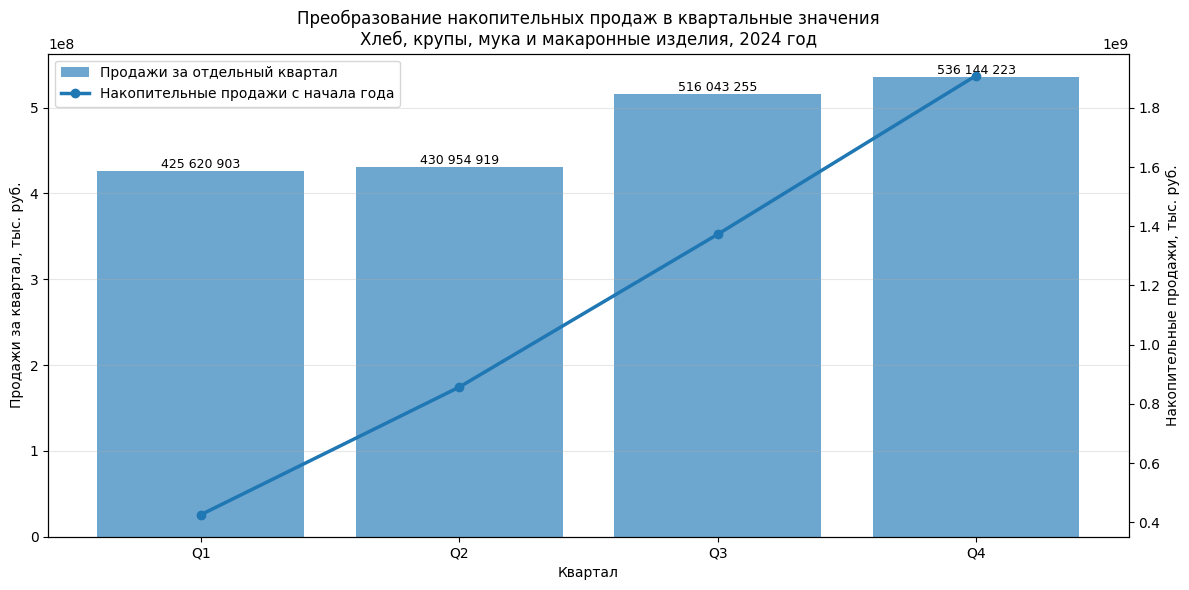

Рисунок сохранён: /content/gdrive/MyDrive/rostat/figures_for_diploma/рисунок_3_2_преобразование_накопительных_продаж_G01_2024.png


In [4]:
# ============================================================
# 4. Рисунок 3.2:
# Преобразование накопительных продаж в квартальные значения
# ============================================================

GROUP_CODE = "G01"
YEAR_TO_PLOT = 2024

g = (
    df[
        (df["product_group_code"] == GROUP_CODE) &
        (df["year"] == YEAR_TO_PLOT)
    ]
    .sort_values("quarter")
    .copy()
)

if g.empty:
    raise ValueError(f"Нет данных для группы {GROUP_CODE} за {YEAR_TO_PLOT} год.")

required_cols = [
    "product_group_name",
    "quarter",
    "sales_quarter_thousand_rub",
    "sales_cumulative_thousand_rub",
]

missing = [c for c in required_cols if c not in g.columns]
if missing:
    raise ValueError(f"В наборе данных нет нужных столбцов: {missing}")

group_name = g["product_group_name"].iloc[0]
g["Квартал"] = "Q" + g["quarter"].astype(str)

# Таблица для демонстрации формул
sales_demo_table = g[
    [
        "Квартал",
        "sales_cumulative_thousand_rub",
        "sales_quarter_thousand_rub",
    ]
].rename(columns={
    "sales_cumulative_thousand_rub": "Накопительные продажи с начала года, тыс. руб.",
    "sales_quarter_thousand_rub": "Продажи за отдельный квартал, тыс. руб.",
})

display(sales_demo_table)

sales_demo_table.to_csv(
    OUT_DIR / f"таблица_преобразование_накопительных_продаж_{GROUP_CODE}_{YEAR_TO_PLOT}.csv",
    index=False,
    encoding="utf-8-sig"
)

fig, ax1 = plt.subplots(figsize=(12, 6))

bars = ax1.bar(
    g["Квартал"],
    g["sales_quarter_thousand_rub"],
    alpha=0.65,
    label="Продажи за отдельный квартал"
)

ax1.set_xlabel("Квартал")
ax1.set_ylabel("Продажи за квартал, тыс. руб.")
ax1.grid(axis="y", alpha=0.3)

for bar, value in zip(bars, g["sales_quarter_thousand_rub"]):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,.0f}".replace(",", " "),
        ha="center",
        va="bottom",
        fontsize=9
    )

ax2 = ax1.twinx()

ax2.plot(
    g["Квартал"],
    g["sales_cumulative_thousand_rub"],
    marker="o",
    linewidth=2.5,
    label="Накопительные продажи с начала года"
)

ax2.set_ylabel("Накопительные продажи, тыс. руб.")

plt.title(
    f"Преобразование накопительных продаж в квартальные значения\n"
    f"{group_name}, {YEAR_TO_PLOT} год"
)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="upper left"
)

plt.tight_layout()

out_path = OUT_DIR / f"рисунок_3_2_преобразование_накопительных_продаж_{GROUP_CODE}_{YEAR_TO_PLOT}.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Рисунок сохранён:", out_path)

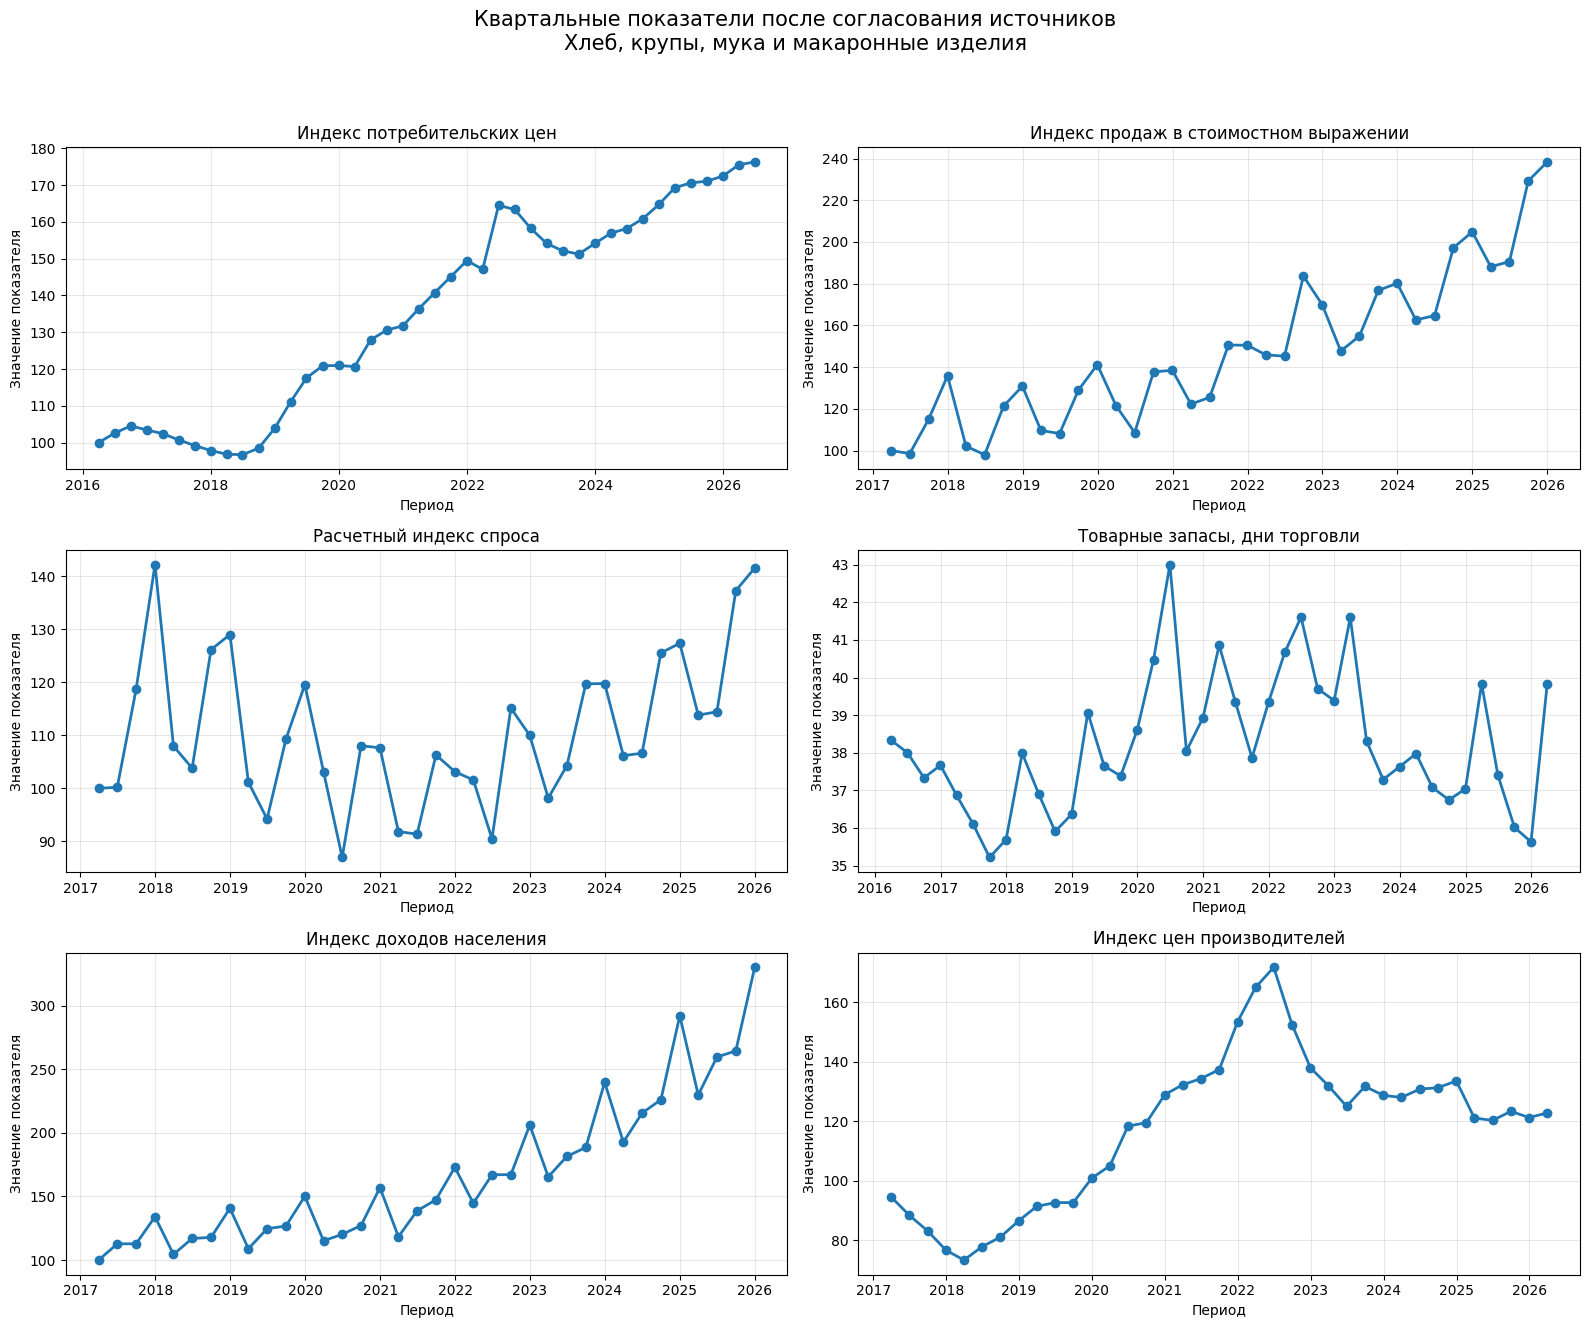

Рисунок сохранён: /content/gdrive/MyDrive/rostat/figures_for_diploma/квартальное_согласование_показателей_G01.png


In [5]:
# ============================================================
# 5. Дополнительный рисунок:
# Итоговое квартальное согласование разных показателей
# ============================================================

GROUP_CODE = "G01"

g = (
    df[df["product_group_code"] == GROUP_CODE]
    .sort_values("period_end")
    .copy()
)

group_name = g["product_group_name"].iloc[0]

# Проверяем, какие показатели есть в файле
plot_columns = [
    ("consumer_price_index", "Индекс потребительских цен"),
    ("sales_value_index", "Индекс продаж в стоимостном выражении"),
    ("real_sales_proxy_index", "Расчетный индекс спроса"),
    ("stock_days_mean", "Товарные запасы, дни торговли"),
    ("per_capita_income_index", "Индекс доходов населения"),
    ("ppi_group_index", "Индекс цен производителей"),
]

available_plot_columns = [
    (col, label)
    for col, label in plot_columns
    if col in g.columns and g[col].notna().sum() > 0
]

if len(available_plot_columns) == 0:
    raise ValueError("Нет доступных показателей для построения графика.")

n = len(available_plot_columns)
ncols = 2
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 4.5 * nrows))
axes = np.array(axes).reshape(-1)

for ax, (col, label) in zip(axes, available_plot_columns):
    ax.plot(
        g["period_end"],
        g[col],
        marker="o",
        linewidth=2
    )

    ax.set_title(label)
    ax.set_xlabel("Период")
    ax.set_ylabel("Значение показателя")
    ax.grid(True, alpha=0.3)

for j in range(len(available_plot_columns), len(axes)):
    axes[j].axis("off")

fig.suptitle(
    f"Квартальные показатели после согласования источников\n{group_name}",
    fontsize=15
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

out_path = OUT_DIR / f"квартальное_согласование_показателей_{GROUP_CODE}.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Рисунок сохранён:", out_path)

In [6]:
# ============================================================
# Рисунок 3.2 — Преобразование накопительных продаж
# в квартальные значения
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_PATH = Path("/content/gdrive/MyDrive/rostat/group_quarterly_dataset.csv")

df = pd.read_csv(DATA_PATH, parse_dates=["period_end"])
df["period_end"] = pd.to_datetime(df["period_end"])

GROUP_CODE = "G01"
YEAR_TO_PLOT = 2024

g = (
    df[
        (df["product_group_code"] == GROUP_CODE) &
        (df["year"] == YEAR_TO_PLOT)
    ]
    .sort_values("quarter")
    .copy()
)

group_name = g["product_group_name"].iloc[0]
g["quarter_label"] = "Q" + g["quarter"].astype(str)

# Если исходные значения в тыс. руб., переводим в млрд руб.
g["sales_quarter_bln_rub"] = g["sales_quarter_thousand_rub"] / 1_000_000
g["sales_cumulative_bln_rub"] = g["sales_cumulative_thousand_rub"] / 1_000_000

plt.figure(figsize=(12, 6))

bars = plt.bar(
    g["quarter_label"],
    g["sales_quarter_bln_rub"],
    alpha=0.65,
    label="Продажи за отдельный квартал"
)

plt.plot(
    g["quarter_label"],
    g["sales_cumulative_bln_rub"],
    marker="o",
    linewidth=2.5,
    label="Накопительные продажи с начала года"
)

for bar, value in zip(bars, g["sales_quarter_bln_rub"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title(
    f"Преобразование накопительных продаж в квартальные значения\n"
    f"{group_name}, {YEAR_TO_PLOT} год"
)

plt.xlabel("Квартал")
plt.ylabel("Объем продаж, млрд руб.")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()

OUT_PATH = Path("/content/gdrive/MyDrive/rostat/figures_for_diploma") / (
    f"рисунок_3_2_преобразование_накопительных_продаж_{GROUP_CODE}_{YEAR_TO_PLOT}.png"
)

OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(OUT_PATH, dpi=300, bbox_inches="tight")
plt.show()

print("Рисунок сохранён:", OUT_PATH)

FileNotFoundError: [Errno 2] No such file or directory: '/content/gdrive/MyDrive/rostat/group_quarterly_dataset.csv'

In [7]:
# ============================================================
# Таблица для пункта 3.3.2:
# Расчет индексов продаж и потребительских цен
# ============================================================

from pathlib import Path
import pandas as pd

try:
    from google.colab import drive
    drive.mount("/content/gdrive")
except Exception:
    pass

BASE_DIR = Path("/content/gdrive/MyDrive/rostat")

possible_paths = [
    BASE_DIR / "csv" / "group_quarterly_dataset.csv",
]

DATA_PATH = None
for path in possible_paths:
    if path.exists():
        DATA_PATH = path
        break

if DATA_PATH is None:
    raise FileNotFoundError(
        "Не найден файл group_quarterly_dataset.csv по пути "
        "/content/gdrive/MyDrive/rostat/csv/group_quarterly_dataset.csv"
    )

OUT_DIR = BASE_DIR / "figures_for_diploma"
OUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH, parse_dates=["period_end"])
df["period_end"] = pd.to_datetime(df["period_end"])

GROUP_CODE = "G01"

g = (
    df[df["product_group_code"] == GROUP_CODE]
    .sort_values("period_end")
    .copy()
)

# Берем несколько строк для демонстрации
demo = g[
    [
        "product_group_name",
        "year",
        "quarter",
        "sales_quarter_thousand_rub",
        "sales_index",
        "mean_price",
        "price_index",
    ]
].head(8).copy()

demo = demo.rename(columns={
    "product_group_name": "Товарная группа",
    "year": "Год",
    "quarter": "Квартал",
    "sales_quarter_thousand_rub": "Продажи за квартал, тыс. руб.",
    "sales_index": "Индекс продаж",
    "mean_price": "Средняя цена, руб.",
    "price_index": "Индекс цен",
})

# Округление для аккуратного вывода
for col in [
    "Продажи за квартал, тыс. руб.",
    "Индекс продаж",
    "Средняя цена, руб.",
    "Индекс цен",
]:
    if col in demo.columns:
        demo[col] = pd.to_numeric(demo[col], errors="coerce").round(2)

display(demo)

demo.to_csv(
    OUT_DIR / f"таблица_3_3_расчет_индексов_продаж_и_цен_{GROUP_CODE}.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Таблица сохранена:", OUT_DIR / f"таблица_3_3_расчет_индексов_продаж_и_цен_{GROUP_CODE}.csv")

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


KeyError: "['sales_index', 'mean_price', 'price_index'] not in index"

In [8]:
# ============================================================
# Таблица для пункта 3.3.2:
# Расчет индексов продаж и потребительских цен
# ============================================================

from pathlib import Path
import pandas as pd

try:
    from google.colab import drive
    drive.mount("/content/gdrive")
except Exception:
    pass

BASE_DIR = Path("/content/gdrive/MyDrive/rostat")

possible_paths = [
    BASE_DIR / "csv" / "group_quarterly_dataset.csv",
]

DATA_PATH = None
for path in possible_paths:
    if path.exists():
        DATA_PATH = path
        break

if DATA_PATH is None:
    raise FileNotFoundError(
        "Не найден файл group_quarterly_dataset.csv по пути "
        "/content/gdrive/MyDrive/rostat/csv/group_quarterly_dataset.csv"
    )

OUT_DIR = BASE_DIR / "figures_for_diploma"
OUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH, parse_dates=["period_end"])
df["period_end"] = pd.to_datetime(df["period_end"])

print("Используется файл:", DATA_PATH)
print("Доступные колонки:")
print(df.columns.tolist())

GROUP_CODE = "G01"

g = (
    df[df["product_group_code"] == GROUP_CODE]
    .sort_values("period_end")
    .copy()
)

# Берем строки, где уже есть продажи.
# В 2016 году продаж может не быть, поэтому начинаем с первых заполненных строк.
g = g[g["sales_value_index"].notna()].copy()

demo = g[
    [
        "product_group_name",
        "year",
        "quarter",
        "sales_quarter_thousand_rub",
        "sales_value_index",
        "consumer_price_index",
        "real_sales_proxy_index",
    ]
].head(8).copy()

demo = demo.rename(columns={
    "product_group_name": "Товарная группа",
    "year": "Год",
    "quarter": "Квартал",
    "sales_quarter_thousand_rub": "Продажи за квартал, тыс. руб.",
    "sales_value_index": "Индекс продаж",
    "consumer_price_index": "Индекс потребительских цен",
    "real_sales_proxy_index": "Расчетный индекс спроса",
})

# Округление
for col in [
    "Продажи за квартал, тыс. руб.",
    "Индекс продаж",
    "Индекс потребительских цен",
    "Расчетный индекс спроса",
]:
    demo[col] = pd.to_numeric(demo[col], errors="coerce").round(2)

display(demo)

out_path = OUT_DIR / f"таблица_3_3_расчет_индексов_продаж_и_цен_{GROUP_CODE}.csv"

demo.to_csv(
    out_path,
    index=False,
    encoding="utf-8-sig"
)

print("Таблица сохранена:", out_path)

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
Используется файл: /content/gdrive/MyDrive/rostat/csv/group_quarterly_dataset.csv
Доступные колонки:
['product_group_code', 'product_group_name', 'period_end', 'year', 'quarter', 'consumer_price_index', 'consumer_price_index_observed_mean', 'n_price_products', 'n_price_products_observed', 'n_price_products_interpolated', 'consumer_price_growth_qoq_pct', 'consumer_price_growth_yoy_pct', 'consumer_price_index_lag1', 'consumer_price_index_lag2', 'consumer_price_index_lag4', 'sales_quarter_thousand_rub', 'sales_cumulative_thousand_rub', 'n_sales_products', 'sales_region', 'sales_region_scope', 'sales_value_index', 'sales_value_growth_qoq_pct', 'sales_value_growth_yoy_pct', 'physical_volume_cumulative_yoy_index', 'n_physical_products', 'physical_volume_cumulative_yoy_index_lag1', 'physical_volume_cumulative_yoy_index_lag2', 'physical_volume_cumulative_yoy_index_

,Товарная группа,Год,Квартал,"Продажи за квартал, тыс. руб.",Индекс продаж,Индекс потребительских цен,Расчетный индекс спроса
4,"Хлеб, крупы, мука и макаронные изделия",2017,1,2.617199e+08,100.00,102.45,100.00
5,"Хлеб, крупы, мука и макаронные изделия",2017,2,2.578767e+08,98.53,100.75,100.19
6,"Хлеб, крупы, мука и макаронные изделия",2017,3,3.008927e+08,114.97,99.21,118.72
7,"Хлеб, крупы, мука и макаронные изделия",2017,4,3.555661e+08,135.86,97.85,142.23
8,"Хлеб, крупы, мука и макаронные изделия",2018,1,2.671137e+08,102.06,96.85,107.96
9,"Хлеб, крупы, мука и макаронные изделия",2018,2,2.564807e+08,98.00,96.71,103.81
10,"Хлеб, крупы, мука и макаронные изделия",2018,3,3.174391e+08,121.29,98.49,126.16
11,"Хлеб, крупы, мука и макаронные изделия",2018,4,3.424796e+08,130.86,103.90,129.03


Таблица сохранена: /content/gdrive/MyDrive/rostat/figures_for_diploma/таблица_3_3_расчет_индексов_продаж_и_цен_G01.csv


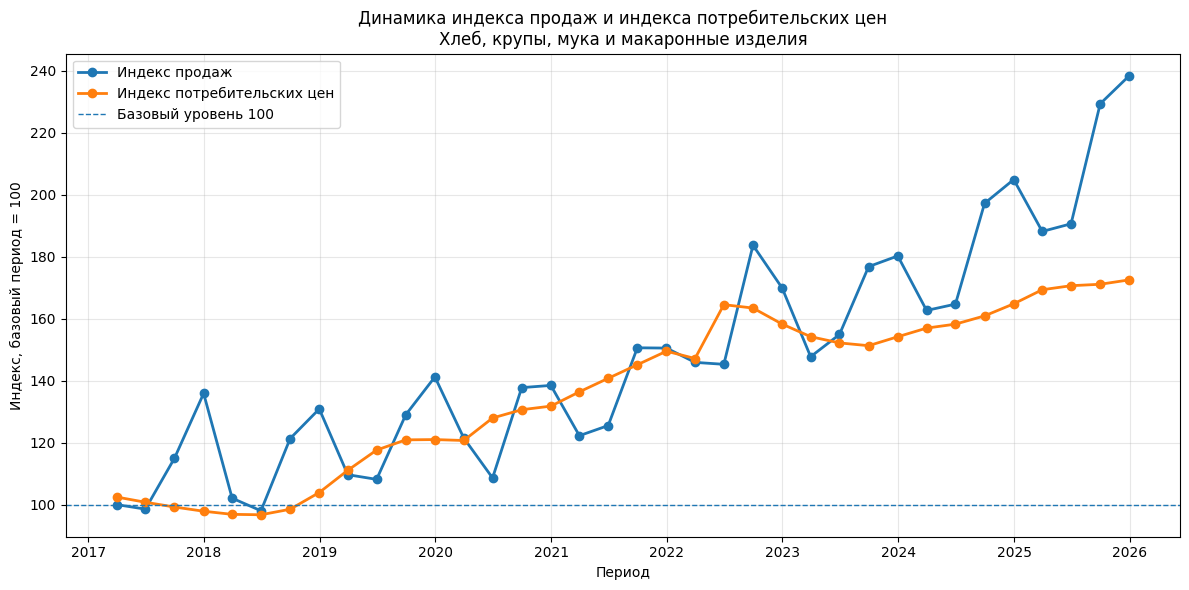

Рисунок сохранен: /content/gdrive/MyDrive/rostat/figures_for_diploma/рисунок_3_3_индексы_продаж_и_цен_G01.png


In [9]:
# ============================================================
# График для пункта 3.3.2:
# Динамика индекса продаж и индекса потребительских цен
# ============================================================

import matplotlib.pyplot as plt

GROUP_CODE = "G01"

g = (
    df[df["product_group_code"] == GROUP_CODE]
    .sort_values("period_end")
    .copy()
)

g = g[
    g["sales_value_index"].notna() &
    g["consumer_price_index"].notna()
].copy()

group_name = g["product_group_name"].iloc[0]

plt.figure(figsize=(12, 6))

plt.plot(
    g["period_end"],
    g["sales_value_index"],
    marker="o",
    linewidth=2,
    label="Индекс продаж"
)

plt.plot(
    g["period_end"],
    g["consumer_price_index"],
    marker="o",
    linewidth=2,
    label="Индекс потребительских цен"
)

plt.axhline(
    100,
    linestyle="--",
    linewidth=1,
    label="Базовый уровень 100"
)

plt.title(
    f"Динамика индекса продаж и индекса потребительских цен\n"
    f"{group_name}"
)

plt.xlabel("Период")
plt.ylabel("Индекс, базовый период = 100")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

out_path = OUT_DIR / f"рисунок_3_3_индексы_продаж_и_цен_{GROUP_CODE}.png"

plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Рисунок сохранен:", out_path)